## Iris Data Set İnceleme

Kaggle üzerinden aldığım bu veri setinde Logistic Regression ve Support Vector Machine ile Classification işlemi yaptım.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv('11-iris.csv')

In [6]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## Sütunların Korelasyon İncelemesi

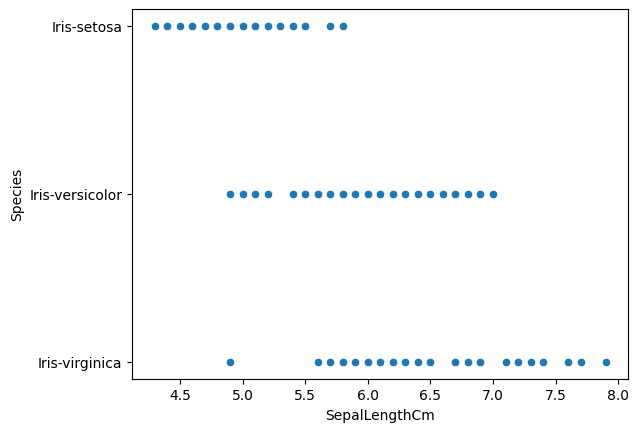

In [14]:
sns.scatterplot(x=data["SepalLengthCm"],y=data["Species"])
plt.show()

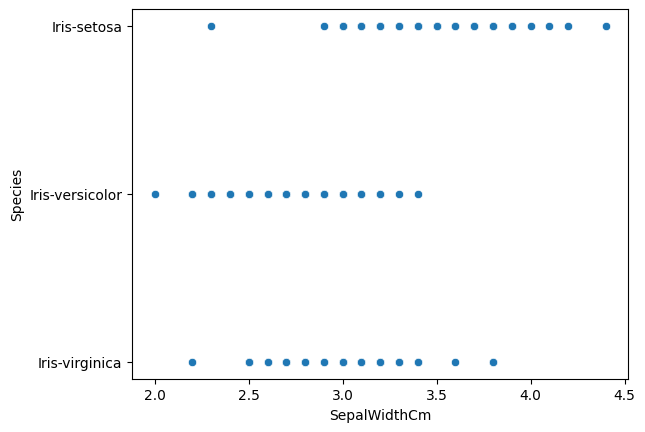

In [16]:
sns.scatterplot(x=data["SepalWidthCm"],y=data["Species"])
plt.show()

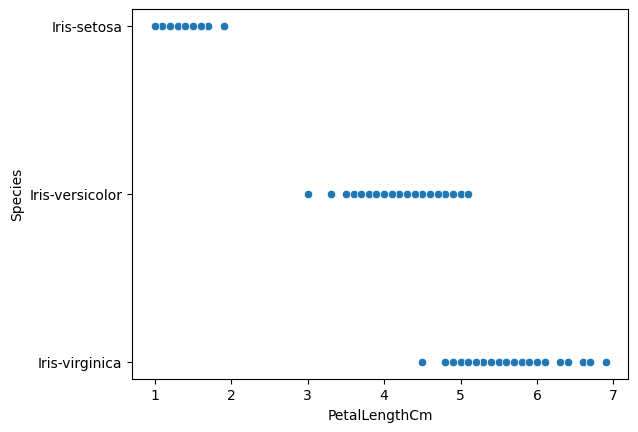

In [18]:
sns.scatterplot(x=data["PetalLengthCm"],y=data["Species"])
plt.show()

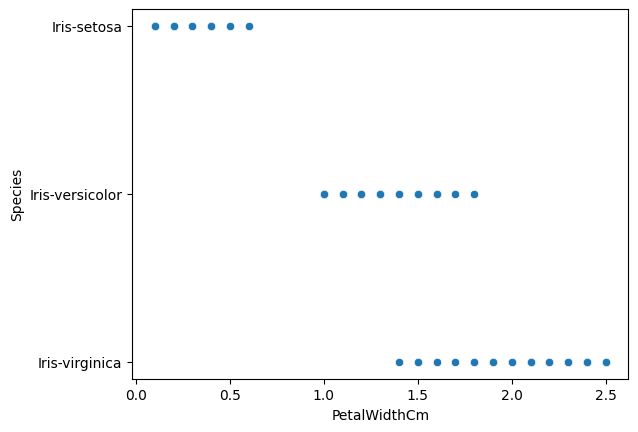

In [24]:
sns.scatterplot(x=data["PetalWidthCm"],y=data["Species"])
plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder

In [30]:
encoder = LabelEncoder()

In [32]:
data["Species"] = encoder.fit_transform(data["Species"])

In [34]:
data.corr()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,1.000000,0.716676,-0.397729,0.882747,0.899759,0.942830
SepalLengthCm,0.716676,1.000000,-0.109369,0.871754,0.817954,0.782561
SepalWidthCm,-0.397729,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
PetalLengthCm,0.882747,0.871754,-0.420516,1.000000,0.962757,0.949043
PetalWidthCm,0.899759,0.817954,-0.356544,0.962757,1.000000,0.956464
Species,0.942830,0.782561,-0.419446,0.949043,0.956464,1.000000


In [75]:
## Tüm sütunlar arasındaki bağıntıyı kontrol ettim. Bağımlı değişkeni korelasyona uygun hale getirdim.

## Model Eğitimi ve Sınıflandırma

In [36]:
cols = ["Id","Species"]

In [38]:
X = data.drop(columns=cols)
y = data["Species"]

In [40]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()

In [44]:
from sklearn.model_selection import train_test_split

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [48]:
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
from sklearn.linear_model import LogisticRegression

In [52]:
log = LogisticRegression()

In [54]:
log.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [56]:
y_pred = log.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [60]:
print("Score:", accuracy_score(y_pred,y_test))
print("Confusion Matrix:", confusion_matrix(y_pred,y_test))
print("Classification Report:",classification_report(y_pred,y_test))

Score: 1.0
Confusion Matrix: [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



## SVC

In [62]:
from sklearn.svm import SVC

In [64]:
svc = SVC()

In [66]:
svc.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [68]:
y_pred = svc.predict(X_test)

In [70]:
print("Score:", accuracy_score(y_pred,y_test))
print("Confusion Matrix:", confusion_matrix(y_pred,y_test))
print("Classification Report:",classification_report(y_pred,y_test))

Score: 1.0
Confusion Matrix: [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



## Genel Özet

Her iki yöntemlede %100lük bir ayrım sağladım. Herhangi bir tuning işlemine gerek kalmadan sınıflandırma işlemini tamamladım. Öğrendiklerimi uygulamak adına güzel bir proje oldu. Feature Engineering kısmında beni zorlayan adımlar olmadı sadece bağımlı değişkeni uygun hale getirdim.